<a href="https://colab.research.google.com/github/kasev/mops/blob/master/scripts/freqs_explorations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pickle
from urllib.request import urlopen
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files
# defining function for saving+downloading the latest figure

def download_figure(fig=None, filename=None):
  if (filename==None) | (".png" not in str(filename)):
    filename = "figure.png"
  if fig==None:
    plt.savefig(filename)
  else:
    fig.savefig(filename)
  files.download(filename)

In [2]:
bidecades_freqs_complete = pickle.load(urlopen("https://github.com/kasev/mops/raw/master/data/bidecades_freqs_complete.pickle"))

In [3]:
palette = sns.color_palette(None, 3)

In [20]:
bidecades_strs = ['1900-1919', '1920-1939', '1940-1959', '1960-1979', '1980-1999', '2000-2019']

from matplotlib.ticker import ScalarFormatter

formatter = ScalarFormatter(useMathText=False)
formatter.set_powerlimits((-8, 8))
formatter.set_scientific(False)

def plot_bidecade_freq(terms, figsize=(6,4)):
    fig, ax = plt.subplots(tight_layout=True, figsize=figsize, dpi=150)
    #fig.patch.set_facecolor("black")
    #ax.set_facecolor("black")
    if type(terms) == list:
        colors = sns.color_palette(None, len(terms))
        for term, color in zip(terms, colors):
            data = [freqs[term] if term in freqs.keys() else 0 for freqs in bidecades_freqs_complete]
            ax.plot(data, linewidth=2, color=color, label=term)
        ax.set_title(", ".join(terms), pad=-14)
    else:
        term = terms
        data = [freqs[term] if term in freqs.keys() else 0 for freqs in bidecades_freqs_complete]
        ax.plot(data, linewidth=2)
        ax.set_title(term, pad=-14)#, color="white")
    ax.set_xticks(range(0,6))
    ax.set_xticklabels(bidecades_strs, rotation=90) # , color="white", rotation=90)
    ax.set_yticks(ax.get_yticks())  # This ensures a fixed set of y-tick positions
    ax.set_yticklabels(['{:.6f}'.format(el) for el in ax.get_yticks()])#  , color="white")
    ax.set_xlabel("bidecade") #, color="white")
    ax.set_ylabel("freq")#, color="white")
    #ax.spines['bottom'].set_color('white')
    #ax.spines['top'].set_color('white')
    #ax.spines['right'].set_color('white')
    #ax.spines['left'].set_color('white')
    ax.legend() #facecolor="black", labelcolor="white")
    return fig

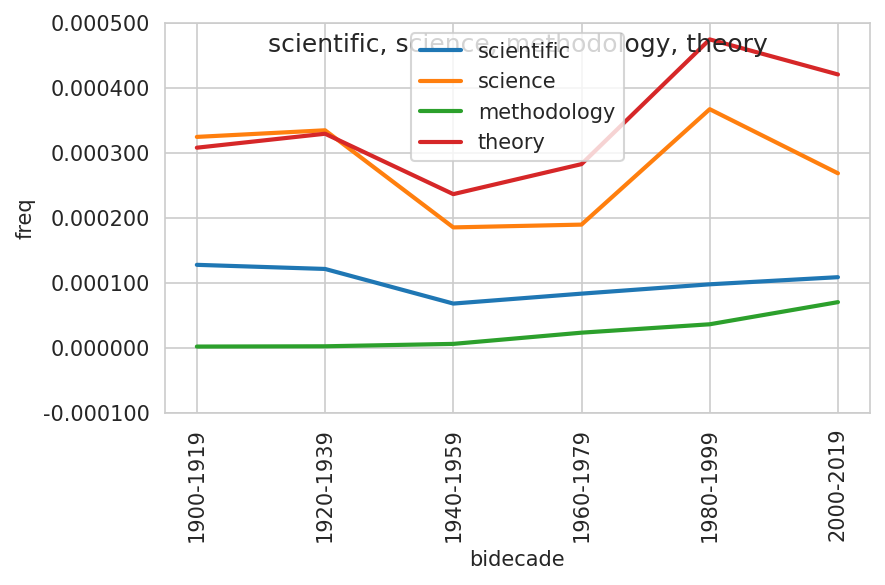

In [21]:
fig = plot_bidecade_freq(["scientific", "science", "methodology", "theory"])

In [ ]:
download_figure(fig)

# Exploring more closely the period from 1990 to 2019

In [8]:
try:
    freqs_2000 = pickle.load(open("../data/freqs_2000.pickle", "rb"))
except:
    freqs_2000 = pickle.load(urlopen("https://github.com/kasev/mops/raw/master/data/freqs_2000.pickle"))

In [22]:
halfdecades_strs = ['1990-1994', '1995-1999', '2000-2004', '2005-2009', '2010-2014', '2015-2019']

def plot_2000_freq(terms, figsize=(6,4)):
    fig, ax = plt.subplots(tight_layout=True, figsize=figsize, dpi=150)
    #fig.patch.set_facecolor("black")
    #ax.set_facecolor("black")
    if type(terms) == list:
        colors = sns.color_palette(None, len(terms))
        for term, color in zip(terms, colors):
            data = [freqs[term] if term in freqs.keys() else 0 for freqs in freqs_2000]
            ax.plot(data, linewidth=2, color=color, label=term)
        ax.set_title(", ".join(terms), pad=-14 ) # , color="white")
    else:
        term = terms
        data = [freqs[term] if term in freqs.keys() else 0 for freqs in freqs_2000]
        ax.plot(data, linewidth=2)
        ax.set_title(term, pad=-14) # , color="white")
    ax.set_xticks(range(0,6))
    ax.set_xticklabels(halfdecades_strs,  rotation=90) # color="white",
    ax.set_yticks(ax.get_yticks())  # This ensures a fixed set of y-tick positions
    ax.set_yticklabels(['{:.6f}'.format(el) for el in ax.get_yticks()]) # , color="white")
    ax.set_xlabel("bidecade") #, color="white")
    ax.set_ylabel("freq") #, color="white")
    #ax.spines['bottom'].set_color('white')
    #ax.spines['top'].set_color('white')
    #ax.spines['right'].set_color('white')
    #ax.spines['left'].set_color('white')
    ax.legend() # facecolor="black", labelcolor="white")
    return fig

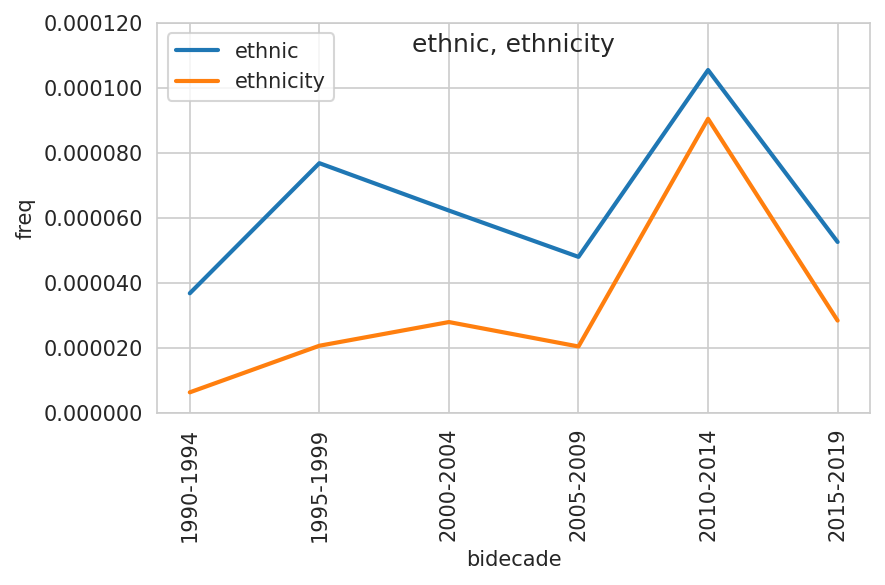

In [23]:
fig = plot_2000_freq(["ethnic", "ethnicity"])

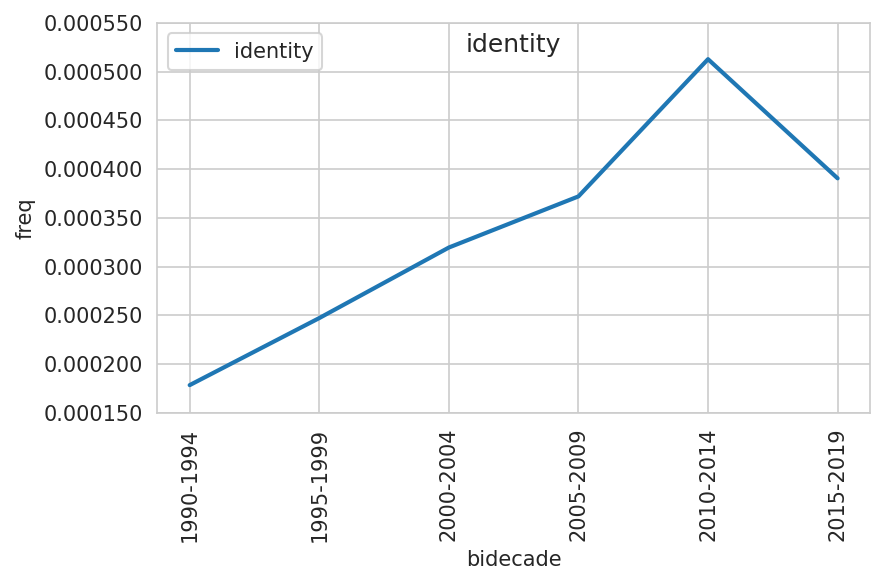

In [24]:
fig = plot_2000_freq(["identity"])
